# Citi Markets Quantitative Analysis - Coffee Commodities

Author: Jeremy Caillaud

Citi MQA job simulation, commodities desk (Arabica coffee). The task has three parts:

1. Pricing a Futures Contract: theoretical price of a coffee futures contract
2. Structuring Securities: pricing an option on that future, then a structured product
3. Managing Risk: measuring and hedging the risk of the position

The notebook follows that order, with an extra Monte Carlo section (section 3) to validate the pricer.

Coffee options listed on ICE are options on the futures contract rather than on physical coffee: exercise delivers a futures position. I therefore use Black-76 instead of Black-Scholes, and check further down that both give the same price once the carry is properly accounted for.

## 0. Market data

All parameters are defined once here and reused throughout the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

S_0 = 2.69 # $/lb, ICO composite indicator on 2026-09-09 (https://icocoffee.org/documents/I-CIP.pdf)
r = 0.0401 # 6-month US Treasury on 2026-09-09
u = 0.01 # annual storage cost (warehousing, insurance, deterioration)
y = 0.00 # convenience yield
T = 0.5
K = 2.80 # $/lb
sigma = 0.25

CONTRACT_SIZE = 37_500 # lbs, ICE Coffee "C" contract

# net holding yield, negative because storing coffee costs money
q = y - u

print(f"Spot: {S_0:.4f} $/lb")
print(f"Risk-free rate: {r:.2%}")
print(f"q: {q:.2%}")

Spot: 2.6900 $/lb
Risk-free rate: 4.01%
q: -1.00%


## 1. Pricing a Futures Contract

### 1.1 Cost of carry

The futures price comes from an arbitrage argument, with no assumption on price dynamics (there is no volatility in the formula). To own coffee in 6 months, you can either buy the physical today and store it, or buy a future. Both strategies must cost the same, otherwise there is an arbitrage.

$$F_0 = S_0 \, e^{(r - q)T} = S_0 \, e^{(r + u - y)T}$$

In [2]:
F_0 = S_0 * np.exp((r - q) * T)

print(f"Fair price of the coffee futures contract: ${F_0:.6f} per pound")
print(f"Basis (F - S): ${F_0 - S_0:.4f} per pound")
print(f"Cost of carry: {r - q:.2%} per year")

Fair price of the coffee futures contract: $2.758236 per pound
Basis (F - S): $0.0682 per pound
Cost of carry: 5.01% per year


### 1.2 Market-implied carry

In practice the future is quoted, and what we actually want is the carry, since $u$ and $y$ are not observable. It can be backed out from the market price:

$$u - y = \frac{1}{T}\ln\!\left(\frac{F_{\text{market}}}{S_0}\right) - r$$

This is a way to check whether the 1% storage assumption is realistic.

In [3]:
F_market = 2.90 # approximate ICE settlement for the target maturity

implied_carry = np.log(F_market / S_0) / T - r

print(f"Theoretical F: {F_0:.4f}, market F: {F_market:.4f}")
print(f"Assumed u - y: {-q:+.2%}")
print(f"Implied u - y: {implied_carry:+.2%}")

Theoretical F: 2.7582, market F: 2.9000
Assumed u - y: +1.00%
Implied u - y: +11.02%


In [4]:
# futures price as a function of the convenience yield
regimes = pd.DataFrame({"y": [0, 0.025, 0.05, 0.075, 0.10]})
regimes["F"] = S_0 * np.exp((r + u - regimes["y"]) * T)
regimes["regime"] = np.where(regimes["F"] > S_0, "contango", "backwardation")

print(f"Backwardation once y > r + u = {r + u:.2%}")
regimes.round(4)

Backwardation once y > r + u = 5.01%


,y,F,regime
0,0.000,2.7582,contango
1,0.025,2.7240,contango
2,0.050,2.6901,contango
3,0.075,2.6567,backwardation
4,0.100,2.6237,backwardation


The market implies a carry of about 11% per year, against 1% assumed. No storage cost can explain a gap that large.

Most of it comes from the quality difference: the ICO index is a global composite that includes Robusta (around \$1.67/lb), while the ICE "C" contract only covers washed Arabica. The spot used here therefore understates the price of physical Arabica.

The table also shows the role of $y$: without a convenience yield, $F > S$ as soon as $r + u > 0$, so the formula can never produce backwardation. Yet coffee regularly goes into backwardation when inventories tighten, and ICE certified stocks are currently at a 27-year low.

## 2. Structuring Securities

### 2.1 Option pricing: Black-76

Since the underlying of the option is the future, we use Black-76:

$$C = e^{-rT}\left[F_0\,\Phi(d_1) - K\,\Phi(d_2)\right],
\qquad d_1 = \frac{\ln(F_0/K) + \frac{\sigma^2}{2}T}{\sigma\sqrt{T}},
\qquad d_2 = d_1 - \sigma\sqrt{T}$$

Unlike Black-Scholes, $r$ does not appear in $d_1$: the future is already a martingale under the risk-neutral measure, so it has no drift.

In [5]:
def black76(F, K, r, sigma, T, kind='call'):
    "Price of a European option on a future (Black-76)"
    d1 = (np.log(F / K) + sigma**2 / 2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == 'call':
        return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

C = black76(F_0, K, r, sigma, T)
P = black76(F_0, K, r, sigma, T, 'put')

print(f"Call price: ${C:.6f} per pound")
print(f"Put price: ${P:.6f} per pound")
print(f"Per contract ({CONTRACT_SIZE:,} lbs): ${C * CONTRACT_SIZE:,.0f}")
print(f"Premium as % of the future: {C / F_0:.2%}")

Call price: $0.172077 per pound
Put price: $0.213012 per pound
Per contract (37,500 lbs): $6,453
Premium as % of the future: 6.24%


### 2.2 Sanity checks

Put-call parity: it does not depend on any model, only on no-arbitrage, so if it fails the error is in the code.

$$C - P = e^{-rT}(F_0 - K)$$

Black-Scholes: with $F_0 = S_0 e^{(r-q)T}$, Black-76 and Black-Scholes with a yield $q$ are the same formula. Plain Black-Scholes would not work here because it assumes zero carry. The carry has to appear in two places, in $d_1$ through $r - q$ and in front of $S_0$ through $e^{-qT}$.

In [6]:
# put-call parity
assert np.isclose(C - P, np.exp(-r * T) * (F_0 - K)), "put-call parity violated"
print(f"C - P = {C - P:.8f}, exp(-rT)(F - K) = {np.exp(-r * T) * (F_0 - K):.8f}")

# Black-Scholes with carry, on the spot
d1_BS = (np.log(S_0 / K) + (r - q + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
d2_BS = d1_BS - sigma * np.sqrt(T)
C_BS = S_0 * np.exp(-q * T) * norm.cdf(d1_BS) - K * np.exp(-r * T) * norm.cdf(d2_BS)

assert np.isclose(C, C_BS), "Black-76 and Black-Scholes should give the same price"
print(f"Black-76: {C:.8f}")
print(f"Black-Scholes: {C_BS:.8f}")
print(f"Difference: {abs(C - C_BS):.2e}")

C - P = -0.04093538, exp(-rT)(F - K) = -0.04093538
Black-76: 0.17207663
Black-Scholes: 0.17207663
Difference: 2.50e-16


### 2.3 Implied volatility

On ICE, coffee options are quoted in price. Implied volatility is the value of $\sigma$ that recovers that price through Black-76. There is no closed-form inverse, so it is solved numerically with Brent's method, which needs no derivative and converges as long as the root is bracketed.

In [7]:
def implied_vol(market_price, F, K, r, T, kind='call'):
    "Inverts Black-76 to recover the implied volatility"
    return brentq(lambda s: black76(F, K, r, s, T, kind) - market_price, 1e-6, 5.0)

# test: starting from the price computed above we should get back 25%
vol = implied_vol(C, F_0, K, r, T)
print(f"Implied volatility: {vol:.4%}")

vol_sensitivity = pd.DataFrame({"sigma": [0.15, 0.20, 0.25, 0.35, 0.50]})
vol_sensitivity["call price"] = black76(F_0, K, r, vol_sensitivity["sigma"], T)
vol_sensitivity.round(4)

Implied volatility: 25.0000%


,sigma,call price
0,0.15,0.0959
1,0.20,0.1340
2,0.25,0.1721
3,0.35,0.2483
4,0.50,0.3621


For coffee, the skew is usually the opposite of equity indices. On the S&P or the CAC, puts are expensive because the tail risk is to the downside. Coffee works the other way round: a frost in Brazil can wipe out part of the crop in a few days and send prices sharply higher, while supply cannot increase quickly since a coffee tree takes three to four years to produce. The tail risk is to the upside, and OTM calls carry the highest implied volatility.

## 3. Monte Carlo

### 3.1 Pricer validation

The price is already known in closed form. The point is to check that the Monte Carlo recovers it, so that it can later be used on products that have no closed-form solution.

Under the risk-neutral measure the future is a martingale, so there is no drift ($\mu$ and $r$ do not appear), only the Ito correction:

$$F_T = F_0 \exp\left[-\frac{\sigma^2}{2}T + \sigma\sqrt{T}\,Z\right], \qquad Z \sim \mathcal{N}(0,1)$$

In [8]:
n_sims = 1_000_000

rng = np.random.default_rng(42)
Z = rng.standard_normal(n_sims)

F_T = F_0 * np.exp(-sigma**2 / 2 * T + sigma * np.sqrt(T) * Z)

payoff = np.maximum(F_T - K, 0)
mc_price = np.exp(-r * T) * payoff.mean()
se = np.exp(-r * T) * payoff.std(ddof=1) / np.sqrt(n_sims)
ci = (mc_price - 1.96 * se, mc_price + 1.96 * se)

print(f"Monte Carlo price: {mc_price:.6f}")
print(f"Standard error: {se:.6f}")
print(f"95% CI: [{ci[0]:.6f}, {ci[1]:.6f}]")
print(f"Black-76: {C:.6f}, inside CI: {ci[0] <= C <= ci[1]}")
print(f"E[F_T]: {F_T.mean():.4f}, F_0: {F_0:.4f}")

Monte Carlo price: 0.172165
Standard error: 0.000297
95% CI: [0.171584, 0.172747]
Black-76: 0.172077, inside CI: True
E[F_T]: 2.7583, F_0: 2.7582


### 3.2 Paths

For a European call only the final price matters, so a single step is enough. The time grid is still discretized to visualize the paths, and because it will be needed for path-dependent payoffs (Asian, barrier).

At each step $T$ is replaced by $dt = T/n$ and the increments are summed inside the exponential.

In [9]:
n_steps = 126 # trading days in 6 months
n_paths = 50

dt = T / n_steps

rng = np.random.default_rng(42)
Z_paths = rng.standard_normal((n_paths, n_steps))

increments = -sigma**2 / 2 * dt + sigma * np.sqrt(dt) * Z_paths
F_paths = F_0 * np.exp(np.cumsum(increments, axis=1))
F_paths = np.hstack((np.full((n_paths, 1), F_0), F_paths))

print(F_paths.shape)

(50, 127)


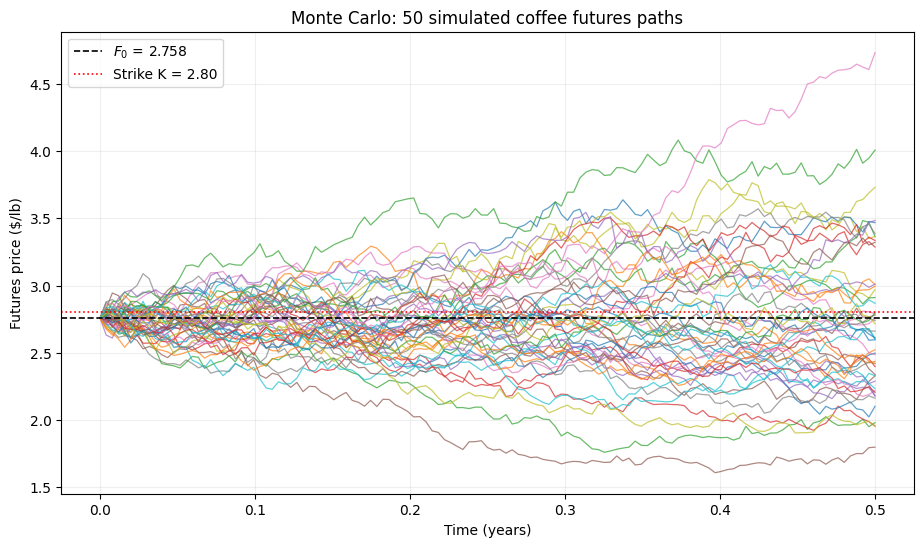

In [10]:
t_grid = np.linspace(0, T, n_steps + 1)

plt.figure(figsize=(11, 6))
plt.plot(t_grid, F_paths.T, lw=0.9, alpha=0.7)
plt.axhline(F_0, color='black', ls='--', lw=1.2, label=f'$F_0$ = {F_0:.3f}')
plt.axhline(K, color='red', ls=':', lw=1.2, label=f'Strike K = {K:.2f}')
plt.xlabel("Time (years)")
plt.ylabel("Futures price ($/lb)")
plt.title(f"Monte Carlo: {n_paths} simulated coffee futures paths")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The cone widens as $\sigma\sqrt{t}$. The distribution is skewed (lognormal): the price can rise a lot but always stays positive.

Geometric Brownian motion has no mean-reverting force, whereas commodity prices tend to revert towards the marginal cost of production, since high prices push producers to plant more. A mean-reverting model such as Schwartz would capture this, with a log-price variance converging to $\sigma^2/2\kappa$ instead of growing indefinitely.

I do not use it here. Over 6 months and for a European payoff on a future, the effect is small, especially since reversion is slow for coffee: new plantations take several years to produce. It would be worth revisiting for a longer-dated or path-dependent product.

### 3.3 Terminal price distribution

The mean of the simulated prices equals $F_0$ by construction. What gives the option its value is the dispersion: with $F_0 = 2.758 < K = 2.80$ we would get $\max(F_0 - K, 0) = 0$, while the call is worth \$0.17. Since the payoff is convex, $E[\max(F_T - K, 0)] \geq \max(E[F_T] - K, 0)$ (Jensen's inequality).

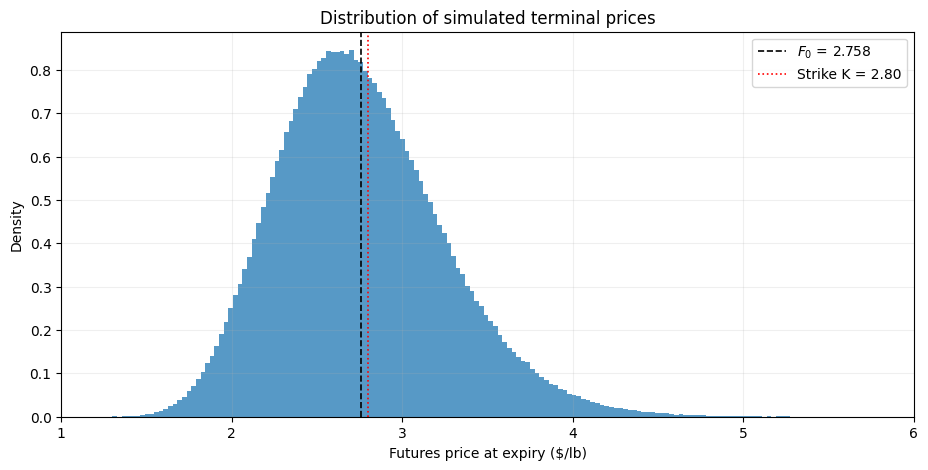

Median: 2.7151
P(F_T > K): 43.09%
5% / 95% quantiles: 2.0291 / 3.6326
max(E[F_T] - K, 0) = 0.0000, C = 0.1721


In [11]:
plt.figure(figsize=(11, 5))
plt.hist(F_T, bins=200, density=True, alpha=0.75, edgecolor='none')
plt.axvline(F_0, color='black', ls='--', lw=1.2, label=f'$F_0$ = {F_0:.3f}')
plt.axvline(K, color='red', ls=':', lw=1.2, label=f'Strike K = {K:.2f}')
plt.xlim(1, 6)
plt.xlabel("Futures price at expiry ($/lb)")
plt.ylabel("Density")
plt.title("Distribution of simulated terminal prices")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Median: {np.median(F_T):.4f}")
print(f"P(F_T > K): {(F_T > K).mean():.2%}")
print(f"5% / 95% quantiles: {np.percentile(F_T, 5):.4f} / {np.percentile(F_T, 95):.4f}")
print(f"max(E[F_T] - K, 0) = {max(F_T.mean() - K, 0):.4f}, C = {C:.4f}")

## 4. Structuring a product

### 4.1 Digital option

A digital (cash-or-nothing) option pays a fixed amount if the underlying ends above the strike, and nothing otherwise. It is the basic building block of conditional coupons.

$$C_{\text{digital}} = e^{-rT}\,\Phi(d_2)$$

$\Phi(d_2)$ is the risk-neutral probability that the option ends in the money, so the price of a digital is simply that probability discounted.

In [12]:
def black76_digital(F, K, r, sigma, T, kind='call'):
    "Cash-or-nothing digital on a future: pays $1 if F_T > K (call) or F_T < K (put)"
    d1 = (np.log(F / K) + sigma**2 / 2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == 'call':
        return np.exp(-r * T) * norm.cdf(d2)
    else:
        return np.exp(-r * T) * norm.cdf(-d2)

digital_call = black76_digital(F_0, K, r, sigma, T)
digital_put = black76_digital(F_0, K, r, sigma, T, 'put')

print(f"Digital call: {digital_call:.4f}")
print(f"Digital put: {digital_put:.4f}")
print(f"Sum: {digital_call + digital_put:.4f}, exp(-rT) = {np.exp(-r * T):.4f}")

# remove the discounting to read the probability
prob_call = digital_call * np.exp(r * T)
print(f"\nP_Q(F_T > K): {prob_call:.2%}")
print(f"Monte Carlo: {(F_T > K).mean():.2%}")

Digital call: 0.4226
Digital put: 0.5575
Sum: 0.9801, exp(-rT) = 0.9801

P_Q(F_T > K): 43.12%
Monte Carlo: 43.09%


$\Phi(d_2)$ is a probability under $\mathbb{Q}$, not the real-world probability that coffee ends above 2.80. The two differ by the risk premium, which is why the VaR in section 5 is simulated under $\mathbb{P}$.

### 4.2 Choosing the strike

The strike is set with the client depending on their risk appetite. The further out it is, the cheaper the digital and the higher the multiple, but the lower the probability of receiving the payout.

In [13]:
payout = 1.0 # $ per unit

digitals = pd.DataFrame({"strike": [2.40, 2.60, F_0, 2.80, 3.00, 3.25, 3.50, 4.00]})
digitals["vs F_0"] = digitals["strike"] / F_0 - 1
digitals["premium"] = black76_digital(F_0, digitals["strike"], r, sigma, T)
digitals["prob Q"] = digitals["premium"] * np.exp(r * T)
digitals["multiple"] = payout / digitals["premium"]

digitals.round({"strike": 4, "vs F_0": 3, "premium": 4, "prob Q": 4, "multiple": 1})

,strike,vs F_0,premium,prob Q,multiple
0,2.4000,-0.130,0.7426,0.7576,1.3
1,2.6000,-0.057,0.5852,0.5971,1.7
2,2.7582,0.000,0.4556,0.4648,2.2
3,2.8000,0.015,0.4226,0.4312,2.4
4,3.0000,0.088,0.2808,0.2865,3.6
5,3.2500,0.178,0.1516,0.1547,6.6
6,3.5000,0.269,0.0740,0.0755,13.5
7,4.0000,0.450,0.0139,0.0142,71.7


At 2.40 the client has roughly a three-in-four chance of receiving the payout, but only multiplies the stake by 1.3. At 4.00 the stake is multiplied by 72, with only a 1.4% chance.

The most common product is still the capital-protected note: a zero-coupon bond that guarantees the capital at maturity, plus an option that provides the upside participation. On \$100 over 6 months, the zero-coupon costs $100 \times e^{-rT}$ and the rest is used to buy the option.

In [14]:
notional = 100.0

zc_cost = notional * np.exp(-r * T)
option_budget = notional - zc_cost

n_calls = option_budget / C
participation = n_calls * F_0 / notional

print(f"Zero-coupon: ${zc_cost:.4f}")
print(f"Option budget: ${option_budget:.4f}")
print(f"Participation: {participation:.1%}")

Zero-coupon: $98.0150
Option budget: $1.9850
Participation: 31.8%


The option budget is only about \$2 per \$100, which limits participation to a little over 30%. The lower the rates, the smaller that budget. In practice the maturity is extended or a cap is added to offer a higher participation rate.

## 5. Managing Risk

### 5.1 Greeks

Greeks are the sensitivities of the price to each parameter. They are what a desk monitors day to day to manage its position.

In [15]:
def greeks76(F, K, r, sigma, T):
    "Greeks of a Black-76 call"
    d1 = (np.log(F / K) + sigma**2 / 2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta = np.exp(-r * T) * norm.cdf(d1)
    gamma = np.exp(-r * T) * norm.pdf(d1) / (F * sigma * np.sqrt(T))
    vega = np.exp(-r * T) * F * norm.pdf(d1) * np.sqrt(T)
    theta = (-np.exp(-r * T) * F * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
             + r * np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2)))
    return delta, gamma, vega, theta

delta, gamma, vega, theta = greeks76(F_0, K, r, sigma, T)

print(f"Delta: {delta:.4f}, i.e. {delta * CONTRACT_SIZE:,.0f} lbs per contract")
print(f"Gamma: {gamma:.4f}")
print(f"Vega: {vega:.4f}, i.e. {vega * 0.01 * CONTRACT_SIZE:,.0f} USD per vol point per contract")
print(f"Theta: {theta:.4f}, i.e. {theta / 365 * CONTRACT_SIZE:,.0f} USD per day per contract")

# check the analytical delta with a central finite difference
h = 1e-5
delta_num = (black76(F_0 + h, K, r, sigma, T) - black76(F_0 - h, K, r, sigma, T)) / (2 * h)
print(f"\nNumerical delta: {delta_num:.6f}")

Delta: 0.4914, i.e. 18,427 lbs per contract
Gamma: 0.8019
Vega: 0.7626, i.e. 286 USD per vol point per contract
Theta: -0.1838, i.e. -19 USD per day per contract

Numerical delta: 0.491395


### 5.2 Comparing three hedges

Take the point of view of a roaster who needs to buy coffee in 6 months and is worried about a price increase:

- future: the price is locked in, but the roaster does not benefit from a fall
- call: protected against a rise while keeping the benefit of a fall, in exchange for a premium
- zero-cost collar: the call is financed by selling a put, so no premium, but the roaster only benefits from a fall down to the put strike

The put strike is set so that the net premium is zero.

In [16]:
# put strike such that the premium of the sold put equals the premium of the bought call
K_put = brentq(lambda k: black76(F_0, k, r, sigma, T, 'put') - C, 1.5, F_0)
print(f"Buy call K = {K:.2f}, sell put K = {K_put:.4f}")

hedges = pd.DataFrame({"F_T": [2.00, 2.40, F_0, 3.00, 3.50, 4.00]})
ft = hedges["F_T"]
hedges["unhedged"] = ft
hedges["future"] = F_0
hedges["call"] = np.minimum(ft, K) + C * np.exp(r * T) # premium compounded to expiry
hedges["collar"] = np.clip(ft, K_put, K)

hedges.round(4)

Buy call K = 2.80, sell put K = 2.7223


,F_T,unhedged,future,call,collar
0,2.0000,2.0000,2.7582,2.1756,2.7223
1,2.4000,2.4000,2.7582,2.5756,2.7223
2,2.7582,2.7582,2.7582,2.9338,2.7582
3,3.0000,3.0000,2.7582,2.9756,2.8000
4,3.5000,3.5000,2.7582,2.9756,2.8000
5,4.0000,4.0000,2.7582,2.9756,2.8000


The future locks the purchase cost at 2.758 in every scenario. The call keeps the benefit of a fall but costs 0.176 of compounded premium, and caps the cost at 2.976. The collar is free, but the purchase cost stays between 2.722 and 2.80.

### 5.3 Stress test

Greeks give a local approximation. For a convex position and a large shock, the Taylor expansion can drift well away from the actual P&L, so the option is fully repriced in each scenario.

The scenarios are based on historical frosts in Brazil (1975, 1994, 2021), which moved prices by several tens of percent within a few days.

In [17]:
N_CONTRACTS = 37
Q_TOTAL = N_CONTRACTS * CONTRACT_SIZE

stress = pd.DataFrame(
    [["Base", 0.00, 0.25],
     ["Moderate frost", 0.15, 0.35],
     ["Severe frost", 0.30, 0.45],
     ["1994 frost", 0.60, 0.60],
     ["Record harvest", -0.20, 0.30]],
    columns=["scenario", "F shock", "sigma"],
).set_index("scenario")

stress["call price"] = black76(F_0 * (1 + stress["F shock"]), K, r, stress["sigma"], T)
stress["P&L"] = (stress["call price"] - C) * Q_TOTAL

print(f"Position: long {N_CONTRACTS} calls, {Q_TOTAL:,} lbs")
stress.round({"call price": 4, "P&L": 0}).astype({"P&L": int})

Position: long 37 calls, 1,387,500 lbs


,F shock,sigma,call price,P&L
scenario,,,,
Base,0.00,0.25,0.1721,0
Moderate frost,0.15,0.35,0.5061,463503
Severe frost,0.30,0.45,0.8928,1000028
1994 frost,0.60,0.60,1.6855,2099910
Record harvest,-0.20,0.30,0.0338,-191898


In [18]:
# Greeks approximation for the severe frost: second order in F, first order in vol
dF = 0.30 * F_0
dsigma = 0.45 - sigma

approx = (delta * dF + 0.5 * gamma * dF**2 + vega * dsigma) * Q_TOTAL
exact = stress.loc["Severe frost", "P&L"]

print(f"Taylor: {approx:,.0f}")
print(f"Full repricing: {exact:,.0f}")
print(f"Difference: {abs(approx - exact) / abs(exact):.1%}")

Taylor: 1,156,745
Full repricing: 1,000,028
Difference: 15.7%


The approximation overstates the P&L by about 16%. It misses both the higher-order terms and the cross terms between price and vol, which are no longer negligible for a shock of this size, all the more since both rise together in a frost. Hence the need to reprice rather than rely on sensitivities.

### 5.4 Value at Risk

The 95% VaR is the loss that should not be exceeded in 95% of cases over the chosen horizon. Since the P&L of an option is not linear in $F$, I compute it by Monte Carlo with a full repricing of the option in each scenario, rather than with a delta-normal approximation.

Here the simulation is run under the historical measure $\mathbb{P}$, with a drift, and not under $\mathbb{Q}$: the goal is no longer a price but the distribution of losses.

In [19]:
horizon = 1 / 252
mu_real = 0.05 # assumed annual drift under P
n_var = 200_000

rng = np.random.default_rng(7)
Z_var = rng.standard_normal(n_var)

F_next = F_0 * np.exp((mu_real - sigma**2 / 2) * horizon + sigma * np.sqrt(horizon) * Z_var)
C_next = black76(F_next, K, r, sigma, T - horizon)
pnl = (C_next - C) * Q_TOTAL

var_95 = -np.percentile(pnl, 5)
cvar_95 = -pnl[pnl <= -var_95].mean()

print(f"Position value: {C * Q_TOTAL:,.0f} USD")
print(f"1-day 95% VaR: {var_95:,.0f} USD")
print(f"1-day 95% CVaR: {cvar_95:,.0f} USD")

Position value: 238,756 USD
1-day 95% VaR: 46,189 USD
1-day 95% CVaR: 56,522 USD


The calculation assumes lognormal returns, so no fat tails. Yet coffee is one of the commodities most exposed to jumps, and a frost produces moves that a continuous diffusion practically never generates.

Under a normal assumption, a daily move of more than 5 standard deviations in a given direction should happen about once every 13,800 years, while commodity markets see several per decade. A lognormal VaR therefore understates the risk, which is one of the reasons FRTB moved to Expected Shortfall and why stress tests are used alongside it.

## 6. Conclusion

The future comes out at \$2.7582/lb and the call at \$0.1721/lb, i.e. \$6,453 per contract. The price is confirmed by put-call parity, by Black-Scholes with carry and by Monte Carlo. The risk-neutral probability of exercise is 43%.

Main limitations:

- There is no single spot price for coffee: physical coffee trades OTC, as a differential to the future, depending on grade and origin. The ICO index mixes Arabica and Robusta, which explains most of the carry gap.
- Volatility is assumed rather than calibrated. It should be taken from the implied volatility of the listed option chain.
- The model has no jumps. A Merton model with an intensity calibrated on historical frosts would fit coffee better, but it would make the market incomplete and delta hedging imperfect.
- Volatility is the same for every strike, whereas the market quotes a skew, which for coffee is tilted towards calls.